In [3]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [5]:
from sklearn.datasets import make_blobs
# `make_blobs`in scikit-learn is a utility function used to generate synthetic datasets for clustering, especially for algorithms like K-Means.
# It creates isotropic Gaussian blobs (clusters) in an N-dimensional space.
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)

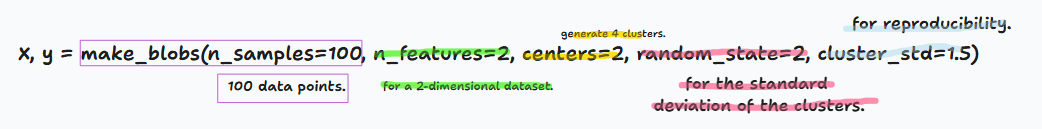

**Key Parameters**  
`n_samples:` int or list — total number of points or per-cluster counts.  
`n_features:` int — number of features (dimensions).  
centers: int or array — number of clusters or specific coordinates for centers.  
`cluster_std:` float or list — standard deviation of clusters.
`center_box:` tuple — min and max bounds for cluster centers.
`random_state:` ensures reproducibility.  
`return_centers:` if True, also returns the actual cluster centers.  

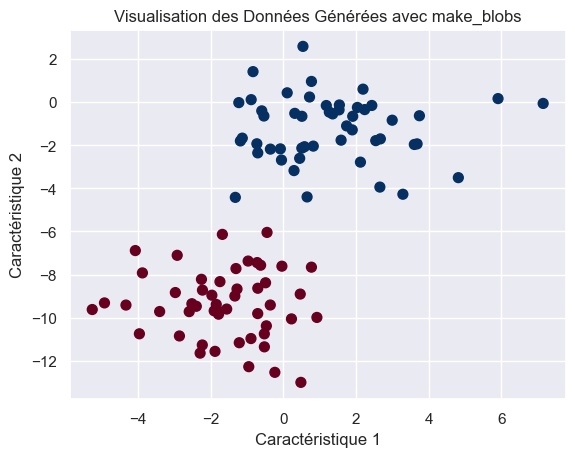

In [6]:
# Visualiser les données
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
plt.title('Visualisation des Données Générées avec make_blobs')
plt.xlabel('Caractéristique 1')
plt.ylabel('Caractéristique 2')
plt.show()

`X[:, 0] `: Les coordonnées x des points (première caractéristique).  
`X[:, 1] `: Les coordonnées y des points (deuxième caractéristique).  
`c=y `: Colore les points en fonction des étiquettes y (chaque cluster aura une couleur différente).  
`s=50 `: Taille des points (50 dans ce cas).  
`cmap='RdBu' `: Carte de couleurs utilisée pour colorer les points (RdBu signifie Red-Blue, donc un cluster sera rouge et l'autre bleu).  


#### make_blobs
Quand tu utilises make_blobs(n_samples=100, n_features=2, centers=2, random_state=2, cluster_std=1.5), tu génères des données qui ressemblent à deux nuages de points (clusters) dans un espace 2D. Par exemple, ces clusters pourraient être centrés autour de points comme (2, 3) et (7, 8) (ces valeurs sont juste des exemples pour illustrer).  

NAIVE BAYES APPLICATION  
**On utilise le modèle Naive Bayes pour prédire à quel cluster appartiennent ces nouveaux points**  

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X,y)#training the model

,priors,None
,var_smoothing,1e-09


In [9]:
#Génère 2000 points aléatoires dans un espace 2D, où chaque coordonnée est un nombre aléatoire entre 0 et 1
rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(2000, 2)
ynew = model.predict(Xnew)

#### Objectif de Xnew
L'objectif de Xnew est de couvrir une zone plus large que celle des données initiales pour voir comment le modèle Naive Bayes prédit les classes dans des régions où il n'a pas été entraîné.


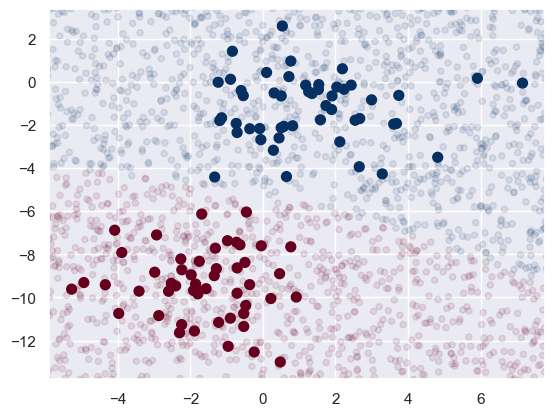

In [10]:
#Trace les données originales X avec leurs étiquettes y.
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
# Enregistre les limites actuelles de l'axe pour les réutiliser plus tard.
lim = plt.axis()
#Trace les nouveaux points de données Xnew avec leurs étiquettes prédites ynew.
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
#Réapplique les limites d'axe enregistrées précédemment pour s'assurer que les nouveaux points ne changent pas l'échelle du graphique.
plt.axis(lim);

Le modèle Naive Bayes trace une ligne horizontale entre les deux groupes pour les séparer. Ensuite, il utilise cette ligne pour prédire à quel groupe appartiennent de nouveaux points sur toute la feuille.

### Résumé

`make_blobs` : Génère des données initiales avec des clusters  bien définis.  
`Xnew` : Génère des points couvrant une zone plus large pour  tester le modèle.  
`model.predict(Xnew)` : Prédit les classes pour ces nouveaux  points.  
`Visualisation` : Montre les frontières de décision du modèle  Naive Bayes. 
  
Cela permet de voir comment le modèle généralise ses prédictions et où il trace les frontières entre les clusters.  


In [ ]:
#Le modèle prédit les probabilités pour chaque point de données dans Xnew.
yprob = model.predict_proba(Xnew)
#On prend les 8 dernières prédictions de probabilité puis On arrondit ces probabilités à 2 décimales pour les rendre plus lisibles.
yprob[-8:].round(2)

array([[0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])